# ANALYSIS

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from pathlib import Path

In [ ]:
BASE_DIR = Path('/scratch/saporito/Frag3D')
FINAL_STEP = 'step_36533'
MASS_THRESHOLD = 1e-6
DENSITY = 2203.0  # kg/m^3

SIM_FOLDERS = [
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_1.5e-02',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_2.5e-02_2.5e-02',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy3.0e+01_thz3.0e+01_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy6.0e+01_thz0.0e+00_sgn1.0e+00_cntr_1.5e-02_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k1.0e-01_sh_circular_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k1.0e-01_sh_parabolic_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy9.0e+01_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_-2.5e-02',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k4.0e-01_sh_circular_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k4.0e-01_sh_parabolic_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+04_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.5e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.7e+03_sf4.0e-01_T4.0e-05_k2.0e-01_sh_gaussian_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00'
]

def make_label(folder: str) -> str:
    m_vel  = re.search(r'vel([^_]+)', folder)
    m_k    = re.search(r'_k([^_]+)', folder)
    m_sh   = re.search(r'sh_([a-zA-Z]+)', folder)
    
    m_thxy = re.search(r'thxy([^_]+)', folder)
    m_thz  = re.search(r'thz([^_]+)',  folder)
    m_cntr = re.search(r'cntr_([0-9.e+\-]+)_([0-9.e+\-]+)', folder)
    
    vel  = float(m_vel.group(1)) if m_vel else 0.0
    k    = float(m_k.group(1)) if m_k else 0.0
    sh   = m_sh.group(1) if m_sh else 'unknown'
    
    thxy   = float(m_thxy.group(1)) if m_thxy else 0
    thz    = float(m_thz.group(1))  if m_thz  else 0
    cx, cy = (float(m_cntr.group(1)), float(m_cntr.group(2))) if m_cntr else (0, 0)
    
    return f'vel={vel:.1e} k={k:.2f} sh={sh} | thxy={thxy:.0f}° thz={thz:.0f}° | cntr=({cx:.2g},{cy:.2g})'

LABELS = [make_label(f) for f in SIM_FOLDERS]
COLORS = plt.cm.tab10(np.linspace(0, 0.5, len(SIM_FOLDERS)))

print('Simulation labels:')
for i, lbl in enumerate(LABELS):
    print(f'  [{i}] {lbl}')

Simulation labels:
  [0] vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)
  [1] vel=1.0e+03 k=0.20 sh=gaussian | thxy=30° thz=30° | cntr=(0.015,0)
  [2] vel=1.0e+03 k=0.20 sh=gaussian | thxy=60° thz=0° | cntr=(0.015,0)
  [3] vel=1.0e+03 k=0.20 sh=gaussian | thxy=90° thz=0° | cntr=(0,-0.025)


In [3]:
SBM_DIR = Path('/home/saporito/NASA-breakup-model-cpp/AkantuComparison/')

SBM_FOLDERS = [
    'circular-k0.1',
    'circular-k0.4',
    'gaussian-angle-k0.2',
    'gaussian-centered-k0.2-v10000',
    'gaussian-centered-k0.2-v1500',
    'gaussian-centered-k0.2-v1700',
    'gaussian-centered-k0.2-xy30-z30',
    'gaussian-centered-k0.2-xy60',
    'gaussian-centered-k0.2-xy90',
    'gaussian-centered-k0.2',
    'gaussian-nearangle-k0.2',
    'gaussian-nearedge-k0.2',
    'parabolic-k0.1',
    'parabolic-k0.4'
]


def parse_velocity_vector(v_str):
    """
    Convert string:
    '[4.523031151046023 -226.04863147567926 -145.7030932365865]'
    -> np.array([x,y,z])
    """
    if pd.isna(v_str):
        return np.zeros(3)

    vals = np.fromstring(
        v_str.strip('[]'),
        sep=' '
    )

    if len(vals) != 3:
        raise ValueError(f'Cannot parse velocity vector: {v_str}')

    return vals


def load_sbm_data(file: Path) -> dict:

    if not file.exists():
        print(f'WARNING: Missing SBM file {file}')
        return None

    df = pd.read_csv(file)

    # keep only target fragments
    df = df[
        df['Name'] == 'Target-Collision-Fragment'
    ].copy()

    # mass threshold
    df = df[
        df['Mass [kg]'] > MASS_THRESHOLD
    ].copy()

    if len(df) == 0:
        return {
            'mass': np.array([]),
            'vmag': np.array([]),
            'vx': np.array([]),
            'vy': np.array([]),
            'vz': np.array([]),
            'ke': np.array([])
        }

    # velocity parsing
    vel_vectors = np.vstack(
        df['Velocity [m/s]']
        .apply(parse_velocity_vector)
        .to_numpy()
    )

    vx = vel_vectors[:, 0]
    vy = vel_vectors[:, 1]
    vz = vel_vectors[:, 2]

    vmag = np.linalg.norm(
        vel_vectors,
        axis=1
    )

    mass = df['Mass [kg]'].to_numpy()

    kinetic_energy = (
        0.5 * mass * vmag**2
    )

    characteristic_length = (
        df['Characteristic Length [m]']
        .to_numpy()
    )

    area = (
        df['Area [m^2]']
        .to_numpy()
    )

    volume = (
        area * characteristic_length
    )

    return {

        'mass': mass,

        'volume': volume,

        'vmag': vmag,
        'vx': vx,
        'vy': vy,
        'vz': vz,

        'ke': kinetic_energy,

        'length': characteristic_length,
        'area_mass': (
            df['A/M [m^2/kg]']
            .to_numpy()
        ),
        'area': area,
    }


# Load both MC and noMC versions
sbm_fragment_data = {}

for folder in SBM_FOLDERS:

    mc_file = (
        SBM_DIR / folder /
        'input-output-MC' /
        'result.csv'
    )

    nomc_file = (
        SBM_DIR / folder /
        'input-output-noMC' /
        'result.csv'
    )

    mc_key = f'{folder} [MC]'
    nomc_key = f'{folder} [noMC]'

    sbm_fragment_data[mc_key] = load_sbm_data(mc_file)
    sbm_fragment_data[nomc_key] = load_sbm_data(nomc_file)

print(
    f'Loaded {len(sbm_fragment_data)} SBM datasets'
)

Loaded 28 SBM datasets


## 1 - Load final-step data for all simulations

In [4]:
SCALAR_ATTRS = ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'total_energy', 'work']

scalar_rows = []
fragment_data = {}

for folder, label in zip(SIM_FOLDERS, LABELS):
    h5path = BASE_DIR / folder / 'data.h5'
    with h5py.File(h5path, 'r') as f:
        step = f[FINAL_STEP]

        row = {'sim': label}
        for attr in SCALAR_ATTRS:
            row[attr] = float(step.attrs[attr])
        masses = step['fragment_mass'][:]
        vels   = step['fragment_velocity'][:]

        row['nb_fragments_heavy'] = int((masses >= MASS_THRESHOLD).sum())
        scalar_rows.append(row)

        vmag = np.linalg.norm(vels, axis=1)
        fragment_data[label] = {

        'mass': masses,

        'volume': (
            masses / DENSITY
        ),

        'vmag': vmag,
        'vx': vels[:, 0],
        'vy': vels[:, 1],
        'vz': vels[:, 2],
    }

print('Done loading', len(scalar_rows), 'simulations.')

Done loading 4 simulations.


## 2 - Energetics table

In [5]:
df_scalar = pd.DataFrame(scalar_rows).set_index('sim')

col_order = ['econ', 'edis', 'ekin', 'epot', 'erev', 'total_energy', 'work',
             'nb_fragments', 'nb_fragments_heavy']
df_scalar = df_scalar[col_order]

col_names = {
    'econ':               'E_con',
    'edis':               'E_dis',
    'ekin':               'E_kin',
    'epot':               'E_pot',
    'erev':               'E_rev',
    'total_energy':       'E_tot',
    'work':               'Work',
    'nb_fragments':       'N_frags',
    'nb_fragments_heavy': f'N_frags (m≥{MASS_THRESHOLD:.0e})',
}
df_display = df_scalar.rename(columns=col_names)

pd.set_option('display.float_format', '{:.4e}'.format)
pd.set_option('display.max_colwidth', None)
display(df_display)

,E_con,E_dis,E_kin,E_pot,E_rev,E_tot,Work,N_frags,N_frags (m≥1e-06)
sim,,,,,,,,,
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)",0.0000e+00,8.2071e-02,8.6383e+01,1.9558e-01,1.5378e-04,8.6661e+01,0.0000e+00,6.6268e+04,153
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=30° thz=30° | cntr=(0.015,0)",0.0000e+00,8.9194e-02,8.6395e+01,2.1912e-01,1.0824e-04,8.6704e+01,0.0000e+00,7.6079e+04,147
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=60° thz=0° | cntr=(0.015,0)",0.0000e+00,9.4798e-02,8.6397e+01,2.3256e-01,1.1031e-04,8.6724e+01,0.0000e+00,8.2393e+04,159
"vel=1.0e+03 k=0.20 sh=gaussian | thxy=90° thz=0° | cntr=(0,-0.025)",0.0000e+00,5.7878e-02,4.3299e+01,1.5273e-01,6.1798e-05,4.3510e+01,0.0000e+00,5.2948e+04,39


## 3 - Fragment statistics table  
mean / max / min / std of mass, |v|, vx, vy, vz

In [6]:
def filter_fragment_data(fragment_data, mass_threshold):
    filtered_data = {}

    for label, fd in fragment_data.items():

        mask = fd['mass'] > mass_threshold

        filtered_data[label] = {
            key: values[mask]
            for key, values in fd.items()
        }

    return filtered_data

fragment_data = filter_fragment_data(
    fragment_data,
    MASS_THRESHOLD
)

In [7]:
FRAG_KEYS = [
    'mass',
    'volume',
    'vmag',
    'vx',
    'vy',
    'vz'
]

FRAG_LABELS = [
    'Mass',
    'Volume',
    '|v|',
    'vx',
    'vy',
    'vz'
]
STAT_FUNCS  = {'mean': np.mean, 'min': np.min, 'max': np.max, 'std': np.std}

rows = []
idx  = []
for label in LABELS:
    fd = fragment_data[label]
    for key, name in zip(FRAG_KEYS, FRAG_LABELS):
        arr = fd[key]
        row = {stat: fn(arr) for stat, fn in STAT_FUNCS.items()}
        rows.append(row)
        idx.append((label, name))

df_stats = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(idx, names=['sim', 'quantity']))
display(df_stats)

mean  \
sim                                                                quantity               
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)   Mass      8.5028e-05   
                                                                   Volume    3.8597e-08   
                                                                   |v|       2.1347e+02   
                                                                   vx        4.5185e-01   
                                                                   vy        9.5939e-01   
                                                                   vz        2.1232e+02   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=30° thz=30° | cntr=(0.015,0) Mass      8.4513e-05   
                                                                   Volume    3.8363e-08   
                                                                   |v|       2.6372e+02   
                                                                   vx        1.3128e+02   
                                                                   vy        1.1357e+02   
                                                                   vz        1.9796e+02   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=60° thz=0° | cntr=(0.015,0)  Mass      7.7471e-05   
                                                                   Volume    3.5166e-08   
                                                                   |v|       2.7612e+02   
                                                                   vx       -9.8735e-01   
                                                                   vy        2.3825e+02   
                                                                   vz        1.3882e+02   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=90° thz=0° | cntr=(0,-0.025) Mass      3.5816e-04   
                                                                   Volume    1.6258e-07   
                                                                   |v|       2.3518e+02   
                                                                   vx       -3.1319e+00   
                                                                   vy        2.3185e+02   
                                                                   vz        7.7058e-02   

                                                                                    min  \
sim                                                                quantity               
vel=1.0e+03 k=0.20 sh=gaussian | thxy=0° thz=0° | cntr=(0.015,0)   Mass      1.0064e-06   
                                                                   Volume    4.5683e-10   
                                                                   |v|       2.7861e+00   
                                                                   vx       -1.4677e+01   
                                                                   vy       -2.6721e+01   
                                                                   vz       -1.1974e+01   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=30° thz=30° | cntr=(0.015,0) Mass      1.0303e-06   
                                                                   Volume    4.6766e-10   
                                                                   |v|       1.0105e+00   
                                                                   vx       -9.2054e-01   
                                                                   vy       -4.5435e-01   
                                                                   vz        5.0281e-01   
vel=1.0e+03 k=0.20 sh=gaussian | thxy=60° thz=0° | cntr=(0.015,0)  Mass      1.0161e-06   
                                                                   Volume    4.6125e-10   
                                                                   |v|       2.7983e+00   
                                                                   vx       -5.4217e+01   
                                                                   vy       -1

## 4 - Distribution plots

In [8]:
from scipy.stats import gaussian_kde

def kde_line(ax, arr, color, label, log_x=False, bw_method='scott'):
    data = arr[arr > 0] if log_x else arr
    if len(data) < 2:
        return
    try:
        if log_x:
            log_data = np.log10(data)
            if np.ptp(log_data) == 0:
                return
            kde = gaussian_kde(log_data, bw_method=bw_method)
            xs_log = np.linspace(log_data.min(), log_data.max(), 500)
            ys = kde(xs_log) / np.log(10)
            xs = 10 ** xs_log
        else:
            if np.ptp(data) == 0:
                return
            kde = gaussian_kde(data, bw_method=bw_method)
            xs = np.linspace(data.min(), data.max(), 500)
            ys = kde(xs)
        ax.plot(xs, ys, color=color, label=label, linewidth=1.8)
        ax.fill_between(xs, ys, alpha=0.12, color=color)
    except Exception:
        return


def plot_kde_combined(frag_data, labels, colors, key, xlabel, log_x=False):
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color in zip(labels, colors):
        if label in frag_data:
            kde_line(ax, frag_data[label][key], color, label, log_x)
            
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.set_title(f'Distribution of {xlabel} - all configs', fontsize=12)
    
    handles, legend_labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=7, framealpha=0.5)
        
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    plt.tight_layout()
    plt.show()


def plot_kde_individual(frag_data, labels, colors, key, xlabel, log_x=False):
    valid_mins = []
    valid_maxs = []
    
    for lbl in labels:
        if lbl in frag_data:
            arr = frag_data[lbl][key]
            data = arr[arr > 0] if log_x else arr
            if len(data) >= 2 and np.ptp(data) > 0:
                valid_mins.append(data.min())
                valid_maxs.append(data.max())
                
    if not valid_mins:
        print(f"Skipping individual plots for {xlabel}: Not enough valid data points.")
        return
        
    xmin, xmax = min(valid_mins), max(valid_maxs)
    
    for label, color in zip(labels, colors):
        if label not in frag_data:
            continue
            
        arr = frag_data[label][key]
        data = arr[arr > 0] if log_x else arr
        if len(data) < 2:
            continue
            
        fig, ax = plt.subplots(figsize=(5, 4))
        kde_line(ax, frag_data[label][key], color, label=None, log_x=log_x)
        
        if log_x:
            ax.set_xscale('log')
        ax.set_xlim(xmin, xmax)
        ax.set_title(label, fontsize=8, wrap=True)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Probability density', fontsize=10)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
        plt.tight_layout()
        plt.show()

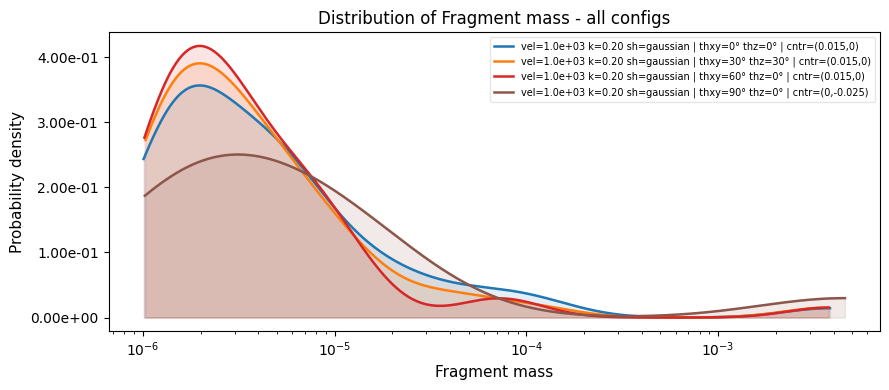

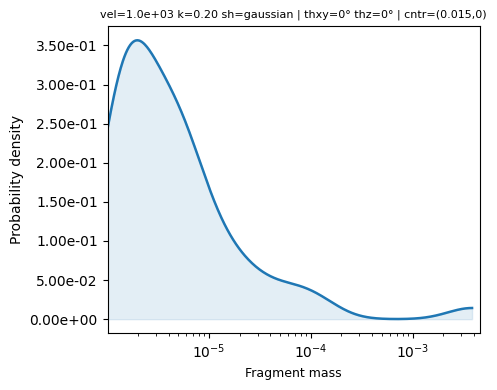

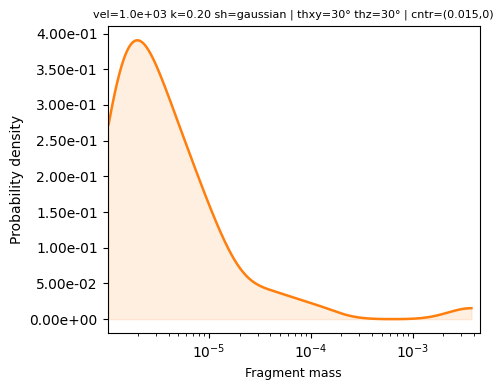

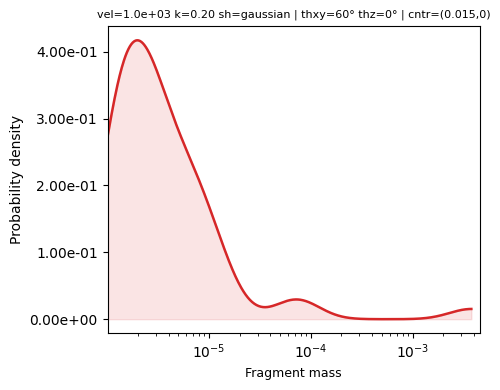

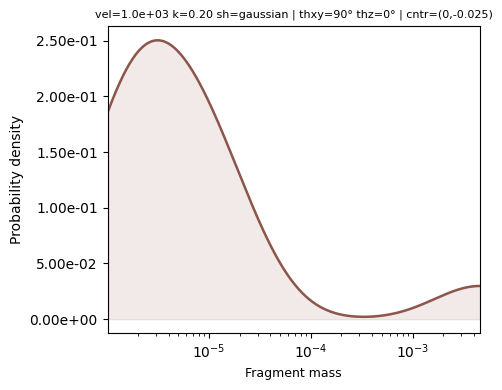

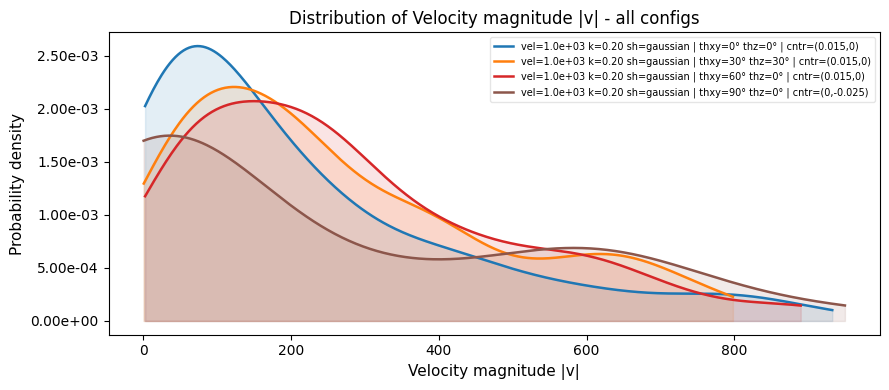

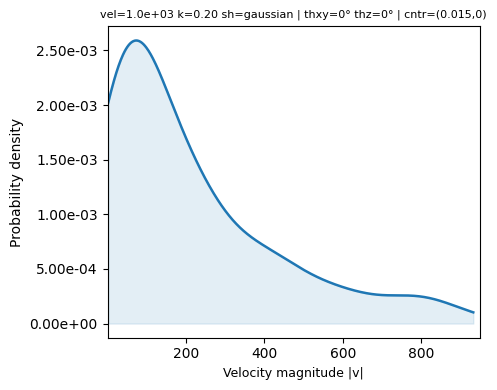

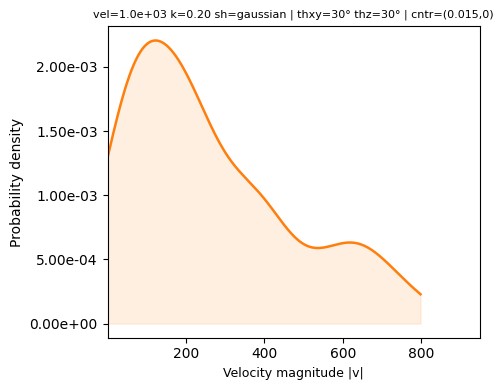

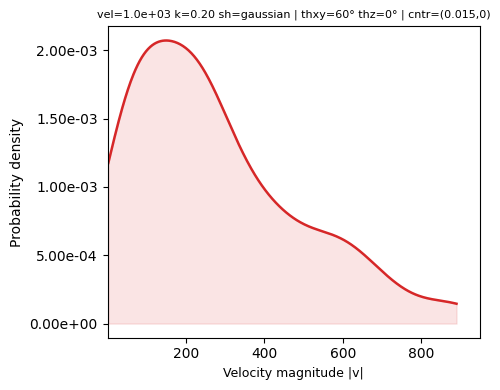

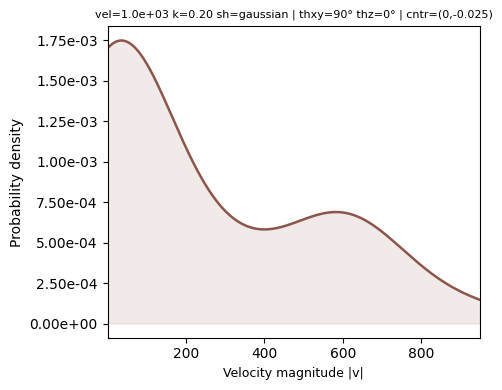

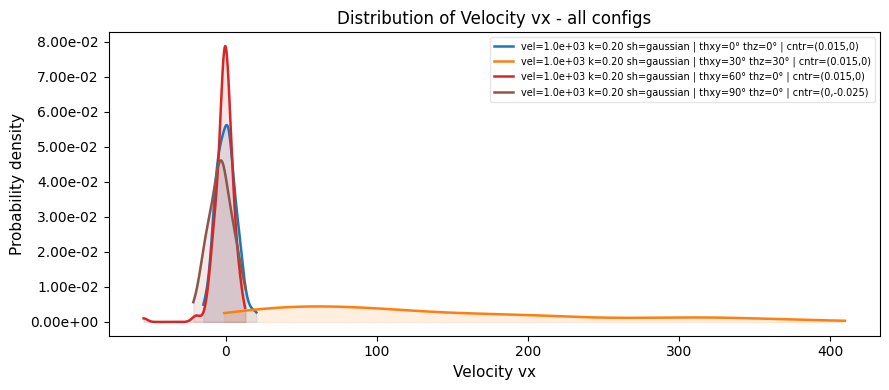

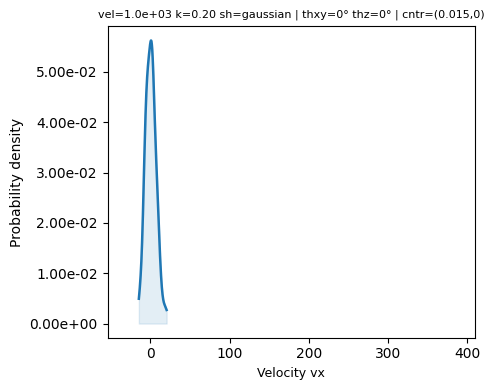

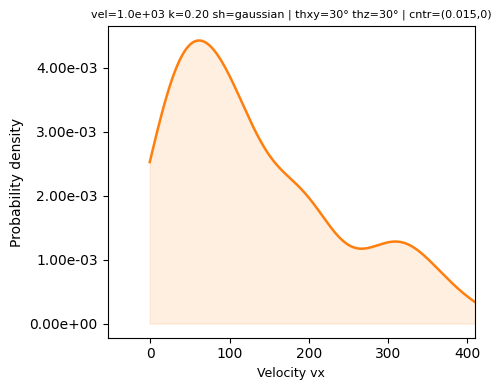

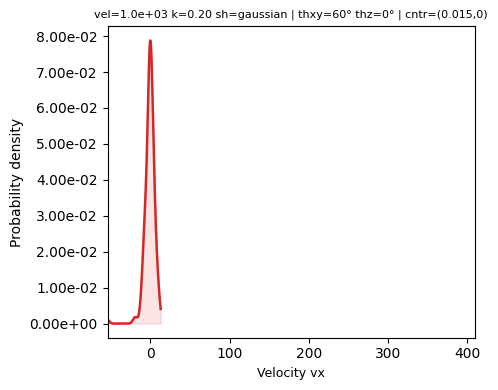

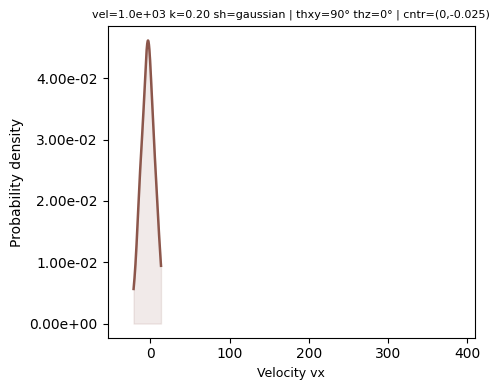

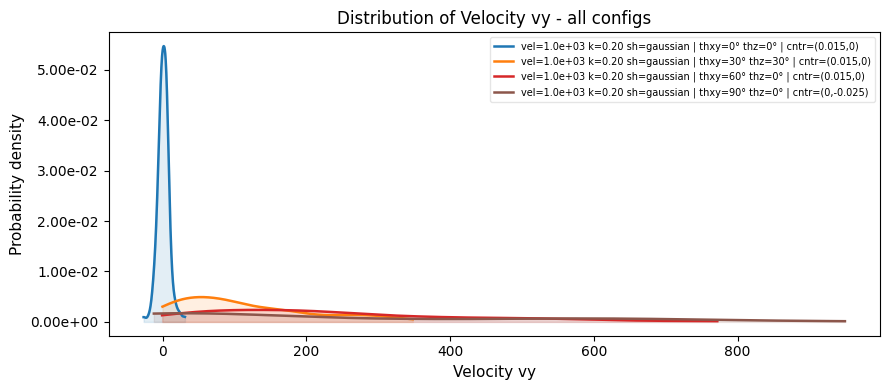

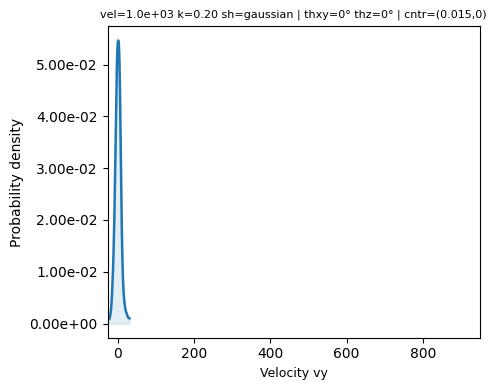

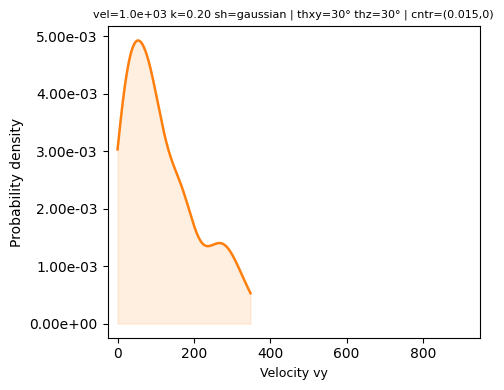

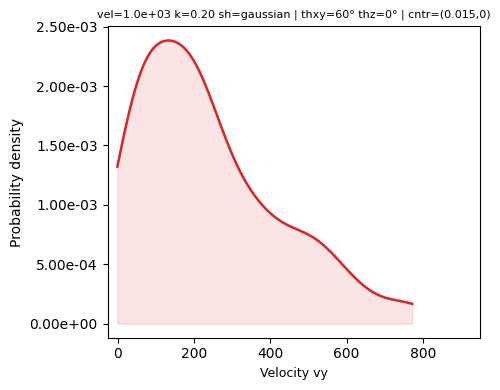

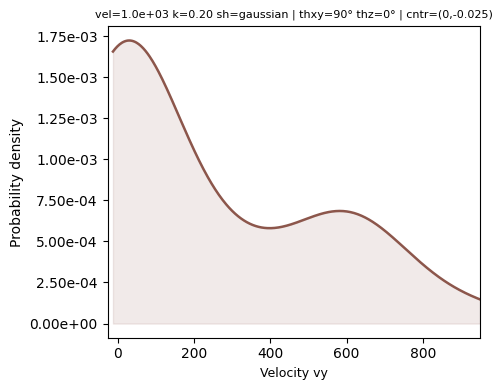

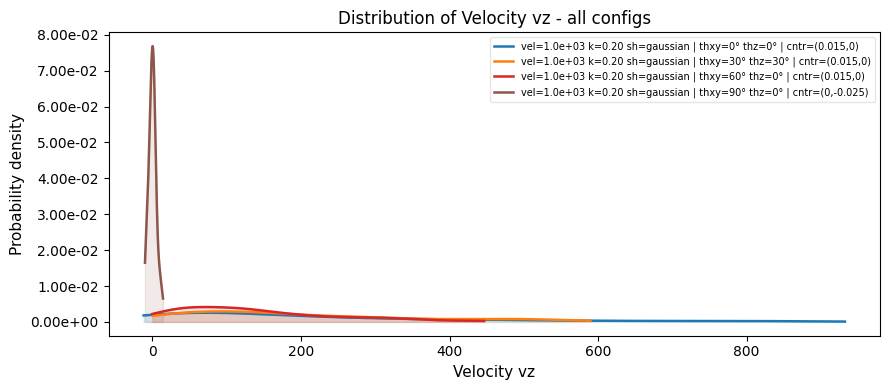

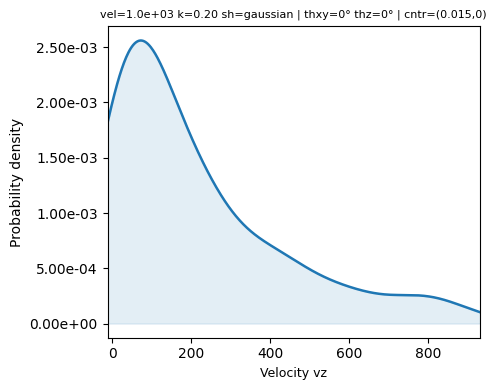

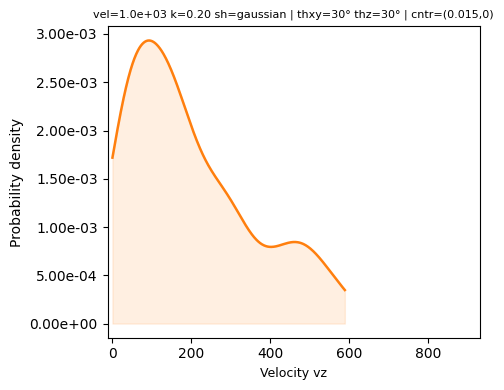

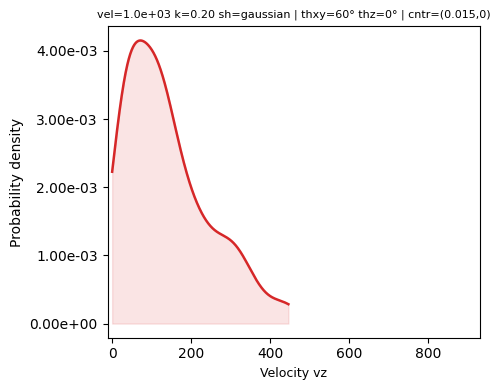

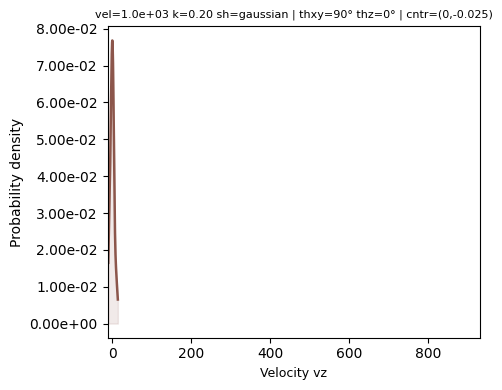

In [9]:
for key, xlabel, log_x in [
    ('mass', 'Fragment mass',          True),
    ('vmag', 'Velocity magnitude |v|', False),
    ('vx',   'Velocity vx',           False),
    ('vy',   'Velocity vy',           False),
    ('vz',   'Velocity vz',           False),
]:
    plot_kde_combined(fragment_data, LABELS, COLORS, key, xlabel, log_x)
    plot_kde_individual(fragment_data, LABELS, COLORS, key, xlabel, log_x)

## 5 - Scatter plot: velocity magnitude vs fragment mass

In [9]:
def scatter_vmag_vs_mass(frag_data, labels, colors, title_suffix='', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        
    for label, color in zip(labels, colors):
        if label in frag_data:
            fd = frag_data[label]
            if len(fd['mass']) == 0: 
                continue
            ax.scatter(fd['mass'], fd['vmag'], s=20, alpha=0.5,
                       color=color, label=label, linewidths=0)
                       
    ax.set_xscale('log')
    ax.set_xlabel('Fragment mass', fontsize=10)
    ax.set_ylabel('Velocity magnitude |v|', fontsize=10)
    ax.set_title(f'|v| vs mass{title_suffix}', fontsize=11)
    
    if standalone:
        handles, legend_labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=7, framealpha=0.5)
        plt.tight_layout()
        plt.show()

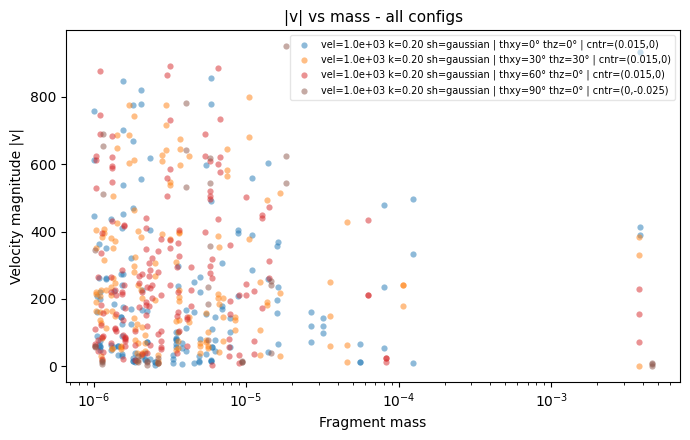

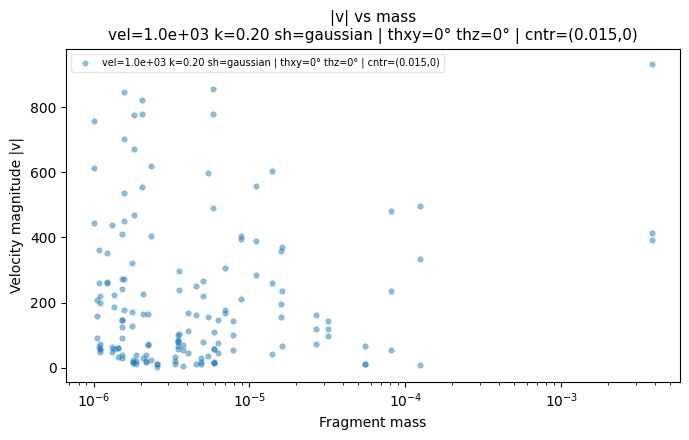

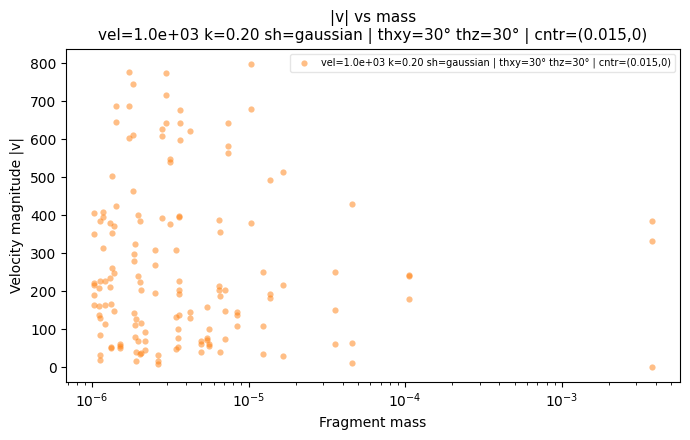

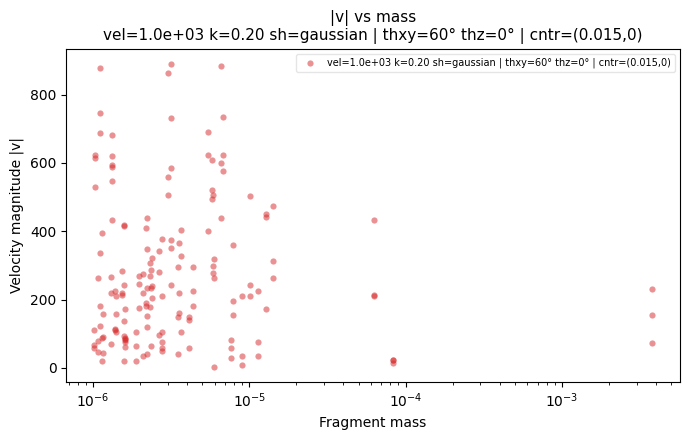

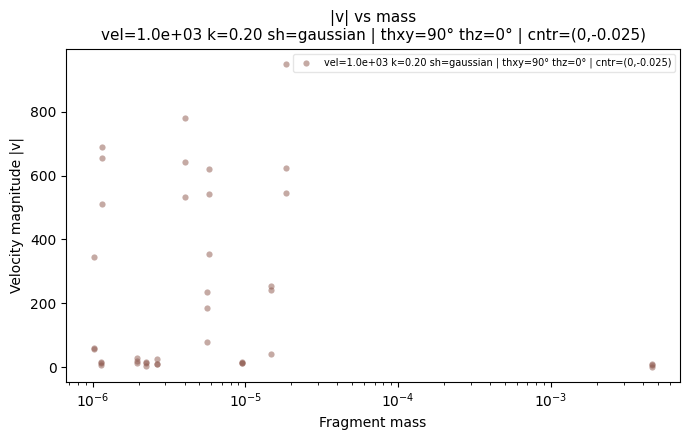

In [10]:
scatter_vmag_vs_mass(
    fragment_data,
    LABELS,
    COLORS,
    title_suffix=' - all configs'
)

for label, color in zip(LABELS, COLORS):
    if label in fragment_data and len(fragment_data[label]['mass']) > 0:
        scatter_vmag_vs_mass(
            fragment_data,
            [label],
            [color],
            title_suffix=f'\n{label}'
        )

In [11]:
AKANTU_SELECTION = [
    LABELS[0],
    LABELS[1],
]

SBM_SELECTION = [
    'gaussian-centered-k0.2 [MC]',
    'gaussian-centered-k0.2 [noMC]',
]

COMPARISON_COLORS = {
    'akantu': plt.cm.Blues,
    'sbm': plt.cm.Reds,
}

In [12]:
# %% ------------------------------------------------------------
# AKANTU + SBM KDE COMPARISON
# ------------------------------------------------------------

def plot_kde_akantu_vs_sbm(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    key,
    xlabel,
    log_x=False,
    figsize=(9, 4)
):

    fig, ax = plt.subplots(figsize=figsize)

    # -----------------------
    # Akantu
    # -----------------------
    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        if label not in akantu_data:
            continue

        kde_line(
            ax=ax,
            arr=akantu_data[label][key],
            color=color,
            label=f'Akantu | {label}',
            log_x=log_x
        )

    # -----------------------
    # SBM
    # -----------------------
    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        if label not in sbm_data:
            continue

        if sbm_data[label] is None:
            continue

        kde_line(
            ax=ax,
            arr=sbm_data[label][key],
            color=color,
            label=f'SBM | {label}',
            log_x=log_x
        )

    if log_x:
        ax.set_xscale('log')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability density')

    ax.set_title(
        f'Akantu vs SBM — {xlabel}'
    )

    ax.yaxis.set_major_formatter(
        ticker.FormatStrFormatter('%.2e')
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

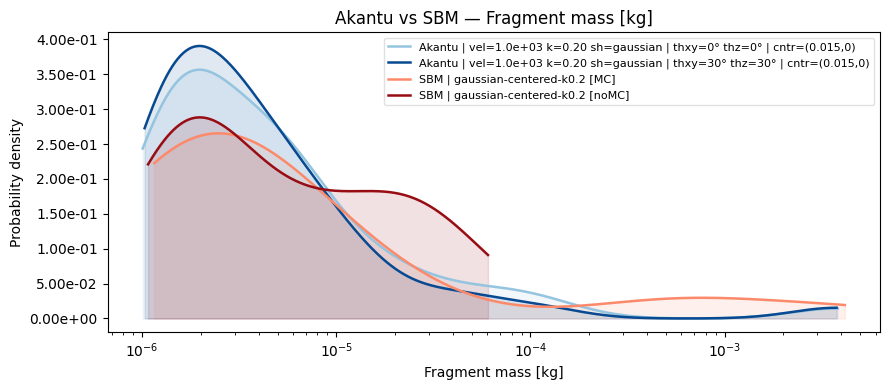

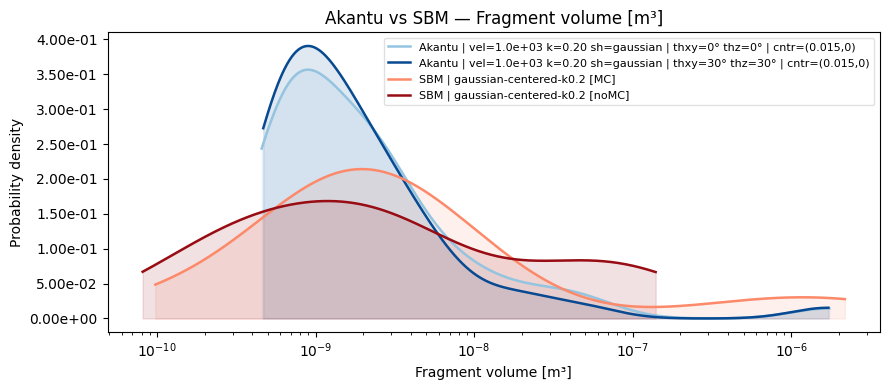

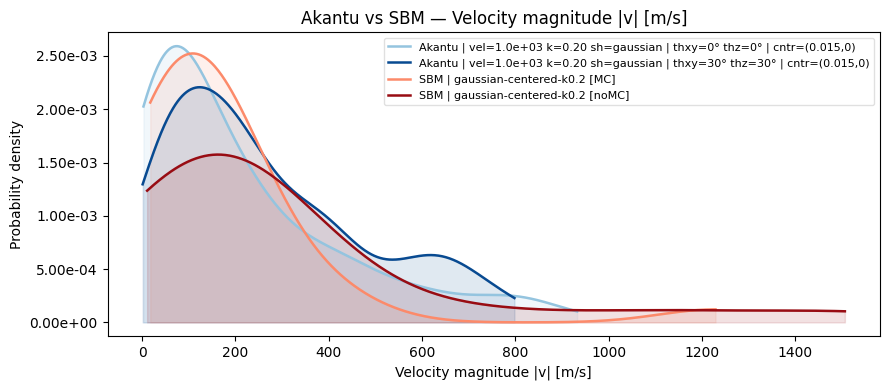

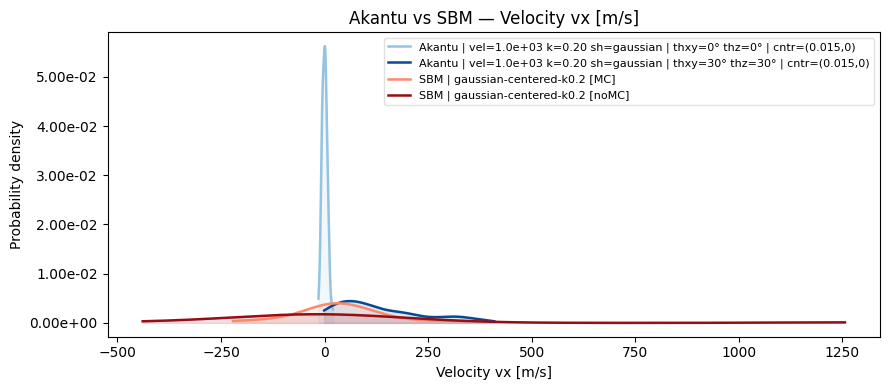

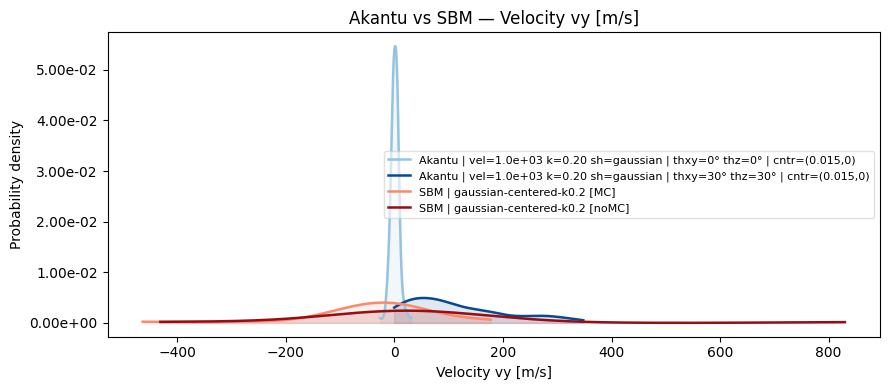

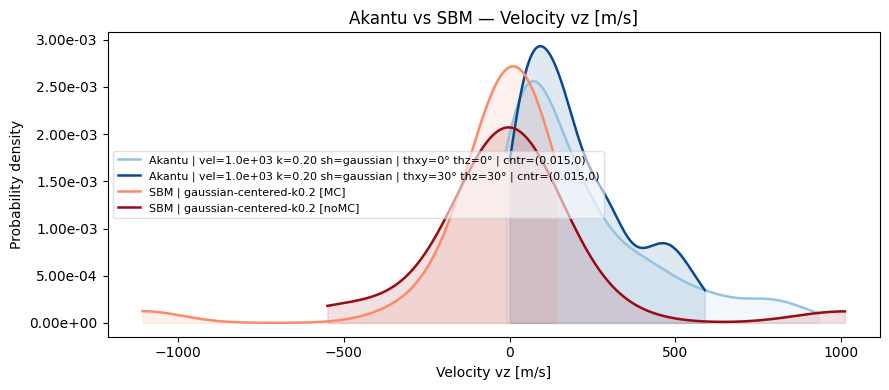

In [13]:
# %% ------------------------------------------------------------
# PLOT ALL DISTRIBUTIONS
# ------------------------------------------------------------

PLOTS = [

    (
        'mass',
        'Fragment mass [kg]',
        True
    ),

    (
        'volume',
        'Fragment volume [m³]',
        True
    ),

    (
        'vmag',
        'Velocity magnitude |v| [m/s]',
        False
    ),

    (
        'vx',
        'Velocity vx [m/s]',
        False
    ),

    (
        'vy',
        'Velocity vy [m/s]',
        False
    ),

    (
        'vz',
        'Velocity vz [m/s]',
        False
    ),
]

for key, xlabel, log_x in PLOTS:

    plot_kde_akantu_vs_sbm(
        akantu_data=fragment_data,
        sbm_data=sbm_fragment_data,
        akantu_selection=AKANTU_SELECTION,
        sbm_selection=SBM_SELECTION,
        key=key,
        xlabel=xlabel,
        log_x=log_x
    )

In [15]:
# %% ------------------------------------------------------------
# AKANTU + SBM SCATTERPLOT
# ------------------------------------------------------------

def scatter_vmag_vs_mass_comparison(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    figsize=(8, 5),
    alpha=0.5,
    marker_size=18
):

    fig, ax = plt.subplots(figsize=figsize)

    # -----------------------
    # Akantu
    # -----------------------
    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        if label not in akantu_data:
            continue

        fd = akantu_data[label]

        if len(fd['mass']) == 0:
            continue

        ax.scatter(
            fd['mass'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'Akantu | {label}'
        )

    # -----------------------
    # SBM
    # -----------------------
    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        if label not in sbm_data:
            continue

        if sbm_data[label] is None:
            continue

        fd = sbm_data[label]

        if len(fd['mass']) == 0:
            continue

        ax.scatter(
            fd['mass'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'SBM | {label}'
        )

    ax.set_xscale('log')

    ax.set_xlabel('Fragment mass [kg]')
    ax.set_ylabel('Velocity magnitude |v| [m/s]')

    ax.set_title(
        'Akantu vs SBM — |v| vs mass'
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

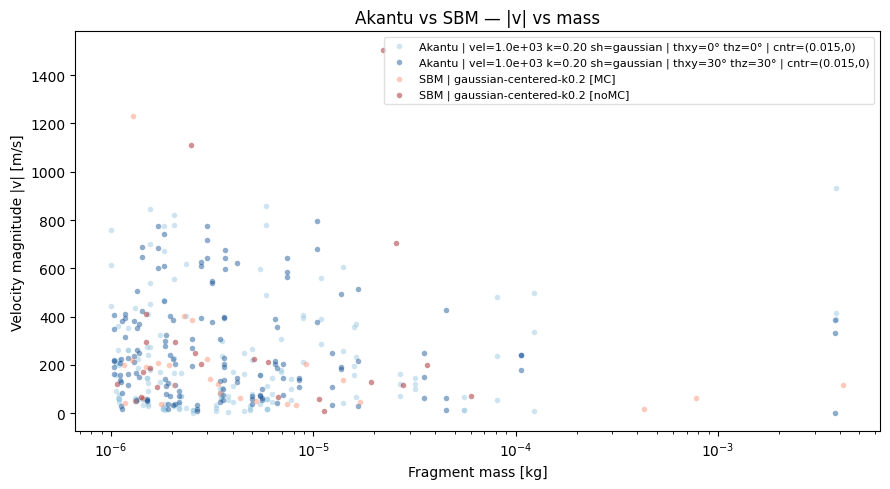

In [16]:
# %% ------------------------------------------------------------
# RUN SCATTERPLOT
# ------------------------------------------------------------

scatter_vmag_vs_mass_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION,
    figsize=(9, 5),
    alpha=0.45,
    marker_size=16
)

In [17]:
# %% ------------------------------------------------------------
# SBM TABLE SELECTION
# ------------------------------------------------------------

SBM_TABLE_SELECTION = [
    'gaussian-centered-k0.2 [MC]',
    'gaussian-centered-k0.2 [noMC]',
    'gaussian-centered-k0.2-xy60 [MC]',
]

In [18]:
# %% ------------------------------------------------------------
# SBM STATISTICS TABLE
# ------------------------------------------------------------

SBM_KEYS = [
    'mass',
    'volume',
    'vmag',
    'vx',
    'vy',
    'vz',
    'ke'
]

SBM_LABELS = [
    'Mass',
    'Volume',
    '|v|',
    'vx',
    'vy',
    'vz',
    'Kinetic Energy'
]
STAT_FUNCS = {
    'mean': np.mean,
    'min': np.min,
    'max': np.max,
    'std': np.std
}

rows = []
idx = []

for dataset in SBM_TABLE_SELECTION:

    if dataset not in sbm_fragment_data:
        print(f'Skipping missing dataset: {dataset}')
        continue

    fd = sbm_fragment_data[dataset]

    if fd is None:
        continue

    for key, name in zip(
        SBM_KEYS,
        SBM_LABELS
    ):

        arr = fd[key]

        if len(arr) == 0:
            row = {
                stat: np.nan
                for stat in STAT_FUNCS
            }
        else:
            row = {
                stat: fn(arr)
                for stat, fn
                in STAT_FUNCS.items()
            }

        rows.append(row)
        idx.append((dataset, name))

df_sbm_stats = pd.DataFrame(
    rows,
    index=pd.MultiIndex.from_tuples(
        idx,
        names=['SBM dataset', 'quantity']
    )
)

pd.set_option(
    'display.float_format',
    '{:.4e}'.format
)

display(df_sbm_stats)

mean         min  \
SBM dataset                      quantity                                 
gaussian-centered-k0.2 [MC]      Mass            2.0304e-04  1.1557e-06   
                                 Volume          1.5059e-07  9.7495e-11   
                                 |v|             1.7384e+02  1.7327e+01   
                                 vx              4.0339e+01 -2.2118e+02   
                                 vy             -3.5598e+01 -4.6393e+02   
                                 vz             -4.5716e+01 -1.1079e+03   
                                 Kinetic Energy  1.2262e+00  1.0004e-03   
gaussian-centered-k0.2 [noMC]    Mass            1.1445e-05  1.0729e-06   
                                 Volume          1.9769e-08  8.1138e-11   
                                 |v|             2.9589e+02  1.0618e+01   
                                 vx              2.2795e+01 -4.3926e+02   
                                 vy              3.4621e+01 -4.3137e+02   
                                 vz              9.9126e+00 -5.5001e+02   
                                 Kinetic Energy  1.5944e+00  6.3989e-04   
gaussian-centered-k0.2-xy60 [MC] Mass            1.9570e-04  1.0316e-06   
                                 Volume          1.1761e-07  1.4125e-10   
                                 |v|             4.0431e+01  2.8073e+00   
                                 vx              5.8943e+00 -7.3589e+01   
                                 vy             -2.4810e+00 -7.4411e+01   
                                 vz              6.3940e+00 -4.5058e+01   
                                 Kinetic Energy  3.0393e+00  5.5364e-06   

                                                       max        std  
SBM dataset                      quantity                              
gaussian-centered-k0.2 [MC]      Mass           4.1682e-03 7.9490e-04  
                                 Volume         2.1795e-06 4.8529e-07  
                                 |v|            1.2289e+03 2.2932e+02  
                                 vx             3.4736e+02 1.1136e+02  
                                 vy             1.7725e+02 1.1985e+02  
                                 vz             1.3962e+02 2.2596e+02  
                                 Kinetic Energy 2.9398e+01 5.5355e+00  
gaussian-centered-k0.2 [noMC]    Mass           6.0491e-05 1.4761e-05  
                                 Volume         1.3958e-07 3.6081e-08  
                                 |v|            1.5062e+03 3.5578e+02  
                                 vx             1.2566e+03 3.0502e+02  
                                 vy             8.2991e+02 2.1701e+02  
                                 vz             1.0125e+03 2.6866e+02  
                                 Kinetic Energy 2.5187e+01 5.3167e+00  
gaussian-centered-k0.2-xy60 [MC] Mass           5.2207e-03 9.6736e-04  
                                 Volume         2.9400e-06 5.4448e-07  
                                 |v|            1.8041e+02 3.6095e+01  
                                 vx             8.9309e+01 2.9358e+01  
                                 vy             1.3326e+02 3.7264e+01  
                                 vz             8.2532e+01 2.4601e+01  
                                 Kinetic Energy 8.4958e+01 1.5765e+01

In [19]:
# %% ------------------------------------------------------------
# VELOCITY VS VOLUME
# ------------------------------------------------------------

def scatter_vmag_vs_volume_comparison(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    figsize=(8, 5),
    alpha=0.5,
    marker_size=18
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        fd = akantu_data[label]

        ax.scatter(
            fd['volume'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'Akantu | {label}'
        )

    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        fd = sbm_data[label]

        ax.scatter(
            fd['volume'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'SBM | {label}'
        )

    ax.set_xscale('log')

    ax.set_xlabel(
        'Fragment volume [m³]'
    )

    ax.set_ylabel(
        'Velocity magnitude |v| [m/s]'
    )

    ax.set_title(
        'Akantu vs SBM — |v| vs volume'
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

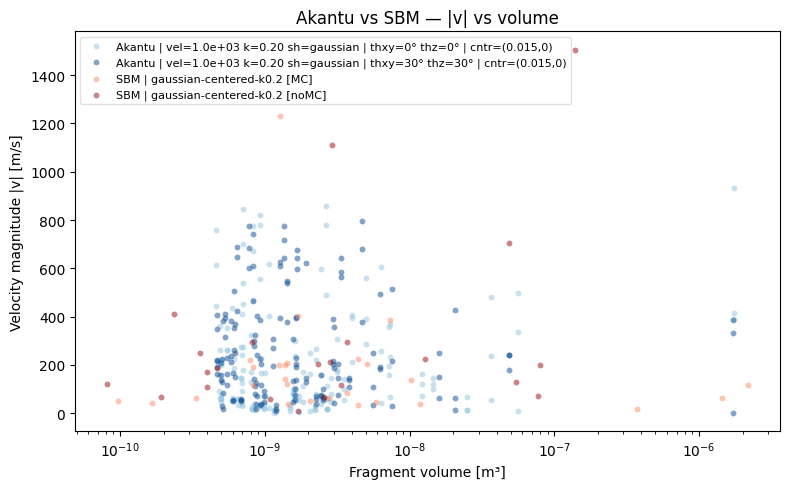

In [20]:
scatter_vmag_vs_volume_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION
)